# **Bioinformatics Project - Computational Drug Discovery [Part 2] Exploratory Data Analysis**


In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 14.1 MB/s eta 0:00:00


## **Install conda and rdkit**

## **Load bioactivity data**

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('bioactivity_preprocessed_data.csv')

## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

In [4]:
!pip install rdkit

### **Import libraries**

In [5]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [6]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [7]:
df_lipinski = lipinski(df.canonical_smiles)

### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [8]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,498.582,4.45860,2.0,6.0
1,497.520,3.96914,2.0,6.0
2,1858.036,-4.81120,24.0,24.0
3,498.582,4.45860,2.0,6.0
4,614.654,3.41680,2.0,8.0
...,...,...,...,...
341,614.654,3.41680,2.0,8.0
342,446.503,3.29960,1.0,4.0
343,859.909,-2.91190,11.0,13.0
344,423.904,3.65602,1.0,5.0


In [9]:
df

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL2402207,COc1ccc(S(=O)(=O)Nc2ccc(NS(=O)(=O)c3ccc(OC)cc3...,2700.0
1,CHEMBL2402206,Cc1ccc(S(=O)(=O)c2cnc(SCC(=O)Nc3ccccc3C(F)(F)F...,118000.0
2,CHEMBL2402205,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](...,33.0
3,CHEMBL2402207,COc1ccc(S(=O)(=O)Nc2ccc(NS(=O)(=O)c3ccc(OC)cc3...,1700.0
4,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,20.0
...,...,...,...
341,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,7.7
342,CHEMBL2381968,O=C(O)[C@H]1CCCC[C@H]1C(=O)N1CCc2ccccc2[C@H]1C...,1400.0
343,CHEMBL5272223,CC(=O)N[C@@H](CC(=O)O)C(=O)N1CSC[C@H]1C(=O)N[C...,31.0
344,CHEMBL1232461,CCNC(=O)C[C@@H]1N=C(c2ccc(Cl)cc2)c2cc(OC)ccc2-...,10000.0


Now, let's combine the 2 DataFrame

In [10]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [11]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL2402207,COc1ccc(S(=O)(=O)Nc2ccc(NS(=O)(=O)c3ccc(OC)cc3...,2700.0,498.582,4.45860,2.0,6.0
1,CHEMBL2402206,Cc1ccc(S(=O)(=O)c2cnc(SCC(=O)Nc3ccccc3C(F)(F)F...,118000.0,497.520,3.96914,2.0,6.0
2,CHEMBL2402205,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](...,33.0,1858.036,-4.81120,24.0,24.0
3,CHEMBL2402207,COc1ccc(S(=O)(=O)Nc2ccc(NS(=O)(=O)c3ccc(OC)cc3...,1700.0,498.582,4.45860,2.0,6.0
4,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,20.0,614.654,3.41680,2.0,8.0
...,...,...,...,...,...,...,...
341,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,7.7,614.654,3.41680,2.0,8.0
342,CHEMBL2381968,O=C(O)[C@H]1CCCC[C@H]1C(=O)N1CCc2ccccc2[C@H]1C...,1400.0,446.503,3.29960,1.0,4.0
343,CHEMBL5272223,CC(=O)N[C@@H](CC(=O)O)C(=O)N1CSC[C@H]1C(=O)N[C...,31.0,859.909,-2.91190,11.0,13.0
344,CHEMBL1232461,CCNC(=O)C[C@@H]1N=C(c2ccc(Cl)cc2)c2cc(OC)ccc2-...,10000.0,423.904,3.65602,1.0,5.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [12]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [13]:
df_combined.standard_value.describe()

,standard_value
count,346.000000
mean,31525.725578
std,94950.708060
min,0.140000
25%,142.500000
50%,1815.000000
75%,27163.000000
max,1000000.000000


In [14]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [15]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [16]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [17]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL2402207,COc1ccc(S(=O)(=O)Nc2ccc(NS(=O)(=O)c3ccc(OC)cc3...,498.582,4.45860,2.0,6.0,2700.0
1,CHEMBL2402206,Cc1ccc(S(=O)(=O)c2cnc(SCC(=O)Nc3ccccc3C(F)(F)F...,497.520,3.96914,2.0,6.0,118000.0
2,CHEMBL2402205,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](...,1858.036,-4.81120,24.0,24.0,33.0
3,CHEMBL2402207,COc1ccc(S(=O)(=O)Nc2ccc(NS(=O)(=O)c3ccc(OC)cc3...,498.582,4.45860,2.0,6.0,1700.0
4,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,614.654,3.41680,2.0,8.0,20.0
...,...,...,...,...,...,...,...
341,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,614.654,3.41680,2.0,8.0,7.7
342,CHEMBL2381968,O=C(O)[C@H]1CCCC[C@H]1C(=O)N1CCc2ccccc2[C@H]1C...,446.503,3.29960,1.0,4.0,1400.0
343,CHEMBL5272223,CC(=O)N[C@@H](CC(=O)O)C(=O)N1CSC[C@H]1C(=O)N[C...,859.909,-2.91190,11.0,13.0,31.0
344,CHEMBL1232461,CCNC(=O)C[C@@H]1N=C(c2ccc(Cl)cc2)c2cc(OC)ccc2-...,423.904,3.65602,1.0,5.0,10000.0


In [18]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,346.000000
mean,31525.725578
std,94950.708060
min,0.140000
25%,142.500000
50%,1815.000000
75%,27163.000000
max,1000000.000000


In [19]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL2402207,COc1ccc(S(=O)(=O)Nc2ccc(NS(=O)(=O)c3ccc(OC)cc3...,498.582,4.45860,2.0,6.0,5.568636
1,CHEMBL2402206,Cc1ccc(S(=O)(=O)c2cnc(SCC(=O)Nc3ccccc3C(F)(F)F...,497.520,3.96914,2.0,6.0,3.928118
2,CHEMBL2402205,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](...,1858.036,-4.81120,24.0,24.0,7.481486
3,CHEMBL2402207,COc1ccc(S(=O)(=O)Nc2ccc(NS(=O)(=O)c3ccc(OC)cc3...,498.582,4.45860,2.0,6.0,5.769551
4,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,614.654,3.41680,2.0,8.0,7.698970
...,...,...,...,...,...,...,...
341,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,614.654,3.41680,2.0,8.0,8.113509
342,CHEMBL2381968,O=C(O)[C@H]1CCCC[C@H]1C(=O)N1CCc2ccccc2[C@H]1C...,446.503,3.29960,1.0,4.0,5.853872
343,CHEMBL5272223,CC(=O)N[C@@H](CC(=O)O)C(=O)N1CSC[C@H]1C(=O)N[C...,859.909,-2.91190,11.0,13.0,7.508638
344,CHEMBL1232461,CCNC(=O)C[C@@H]1N=C(c2ccc(Cl)cc2)c2cc(OC)ccc2-...,423.904,3.65602,1.0,5.0,5.000000


In [20]:
df_final.pIC50.describe()

,pIC50
count,346.000000
mean,5.783669
std,1.342148
min,3.000000
25%,4.566023
50%,5.741125
75%,6.846381
max,9.853872


### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [21]:
def classify_bioactivity(pIC50_value):
    if pIC50_value >= 6.0:
        return 'active'
    elif pIC50_value <= 5.0:
        return 'inactive'
    else:
        return 'intermediate'

df_final['bioactivity_class'] = df_final['pIC50'].apply(classify_bioactivity)

df_2class = df_final[df_final.bioactivity_class != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
1,CHEMBL2402206,Cc1ccc(S(=O)(=O)c2cnc(SCC(=O)Nc3ccccc3C(F)(F)F...,497.520,3.96914,2.0,6.0,3.928118,inactive
2,CHEMBL2402205,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](...,1858.036,-4.81120,24.0,24.0,7.481486,active
4,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,614.654,3.41680,2.0,8.0,7.698970,active
6,CHEMBL3632707,CCOC(=O)CN(c1ccc(N(CC(=O)OCC)S(=O)(=O)c2ccc(OC...,670.762,4.37380,0.0,10.0,3.602060,inactive
7,CHEMBL3632711,COc1ccc(S(=O)(=O)N(CC(N)=O)c2ccc(N(CC(N)=O)S(=...,612.686,2.21820,2.0,8.0,7.356547,active
...,...,...,...,...,...,...,...,...
340,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,614.654,3.41680,2.0,8.0,7.619789,active
341,CHEMBL3237245,COc1ccc(S(=O)(=O)N(CC(=O)O)c2ccc(N(CC(=O)O)S(=...,614.654,3.41680,2.0,8.0,8.113509,active
343,CHEMBL5272223,CC(=O)N[C@@H](CC(=O)O)C(=O)N1CSC[C@H]1C(=O)N[C...,859.909,-2.91190,11.0,13.0,7.508638,active
344,CHEMBL1232461,CCNC(=O)C[C@@H]1N=C(c2ccc(Cl)cc2)c2cc(OC)ccc2-...,423.904,3.65602,1.0,5.0,5.000000,inactive


In [22]:
from google.colab import files

df_2class.to_csv('bioactivity_data_2class.csv', index=False)
files.download('bioactivity_data_2class.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [23]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

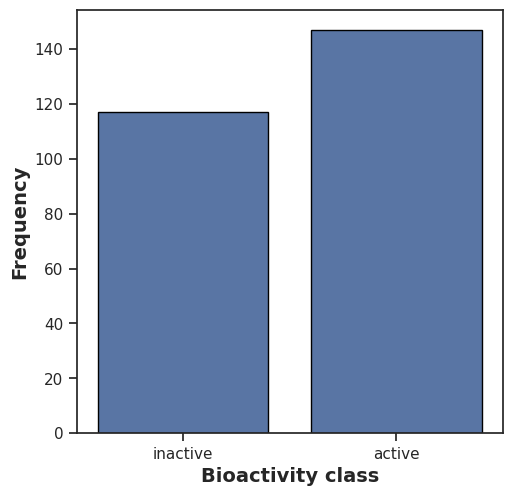

In [24]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

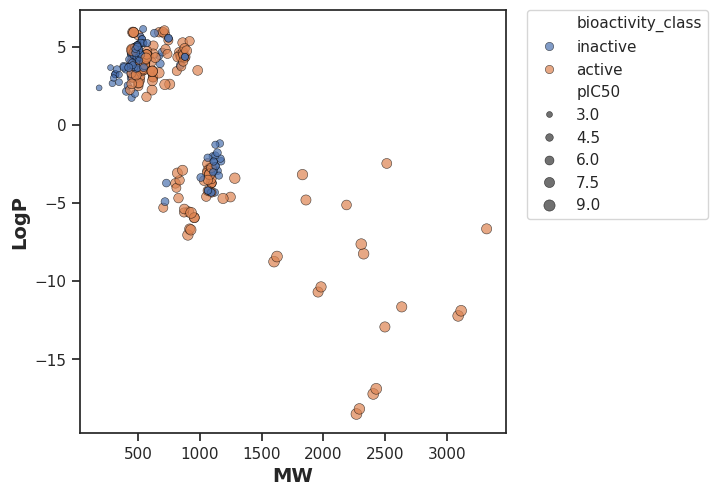

In [25]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

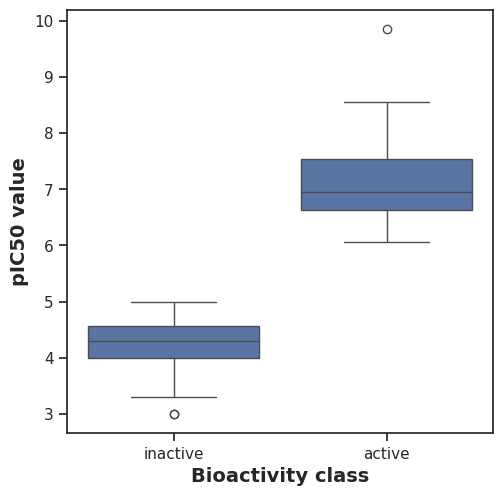

In [26]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [27]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [28]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,17199.0,2.671146e-44,0.05,Different distribution (reject H0)


#### **MW**

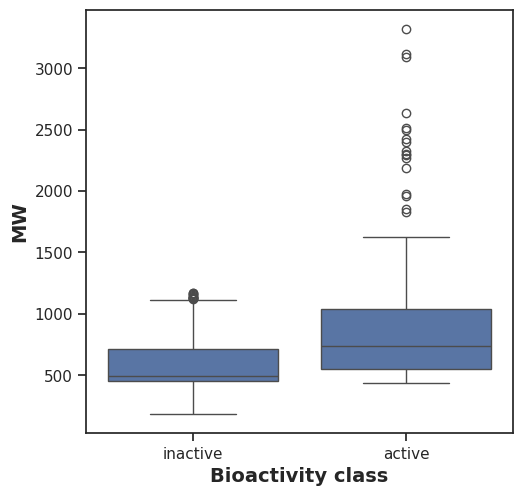

In [29]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [30]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,12247.5,3.245095e-09,0.05,Different distribution (reject H0)


#### **LogP**

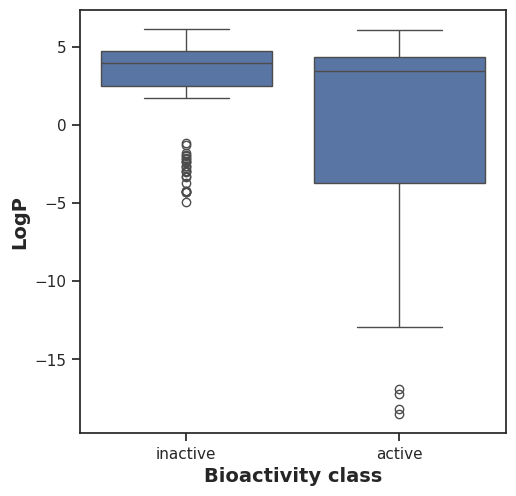

In [31]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [32]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,6265.0,0.000152,0.05,Different distribution (reject H0)


#### **NumHDonors**

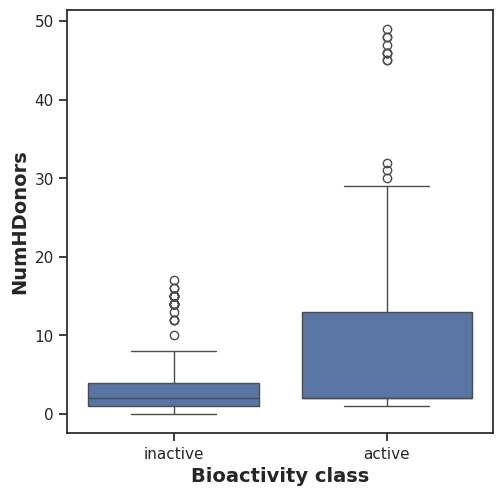

In [33]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [34]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,10769.5,0.000315,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

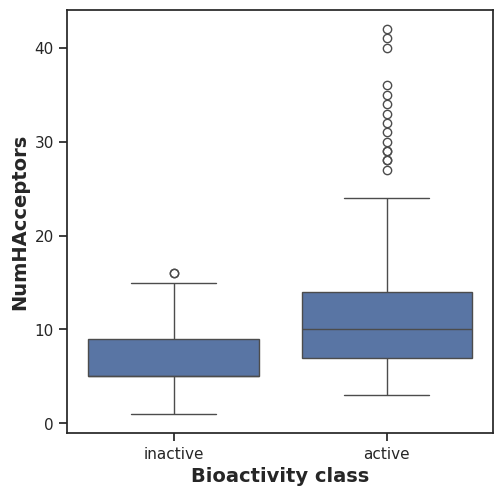

In [35]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [36]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,12405.0,5.559877e-10,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors and NumHAcceptors), only LogP exhibited ***no difference*** between the **actives** and **inactives** while the other 3 descriptors (MW, NumHDonors and NumHAcceptors) shows ***statistically significant difference*** between **actives** and **inactives**.

## **Zip files**

In [37]:
! zip -r results.zip . -i *.csv *.pdf

  adding: plot_bioactivity_class.pdf (deflated 38%)
  adding: plot_ic50.pdf (deflated 36%)
  adding: plot_NumHDonors.pdf (deflated 38%)
  adding: plot_MW_vs_LogP.pdf (deflated 9%)
  adding: mannwhitneyu_MW.csv (deflated 9%)
  adding: plot_NumHAcceptors.pdf (deflated 39%)
  adding: bioactivity_preprocessed_data.csv (deflated 88%)
  adding: mannwhitneyu_LogP.csv (deflated 10%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
  adding: mannwhitneyu_pIC50.csv (deflated 10%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 10%)
  adding: plot_MW.pdf (deflated 39%)
  adding: bioactivity_data_2class.csv (deflated 83%)
  adding: plot_LogP.pdf (deflated 40%)
